# Задача 9. Hand-crafted graph features

## Задача

- [x] Найти или сгенерировать набор данных для бинарной классификации графов.
- [x] Реализовать функцию `shortest_path_kernel(train_graphs, test_graphs)`, которая принимает тренировочный и тестовые наборы, а возвращает пару `K_train, K_test`
  - Опишите графы с помощью вектора из количества кратчайших путей различной длины
  - Для вычисления длин кратчайших путей можно использовать `nx.shortest_path_length(G)`
  - Ядровая функция для сравнения двух графов - скалярное произведение их двух векторов
  - `K_train` - матрица из ядровых функций для сравнения тренировочных графов между собой
  - `K_test` - матрица из ядровых функций для сравнения тестовых графов с тренировочными
- [x] Используя реализованное ядро обучите модель SVC, подберите гиперпараметры, вычислите различные метрики качества
- [x] (+5 баллов) Также реализовать Weisfeiler-Lehman Kernel и обучить классификатор с ним, сравнить результаты.

## Импорты

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)

## Генерация датасета

Для задачи бинарной классификации нам нужны два класса графов, которые структурно отличаются, но не тривиально - иначе любой простой признак легко разделит классы.

Генерируем:
- **Класс 0 - Multigraph (`MG`)**: несколько хабов, соединённых между собой случайным образом, к каждому хабу прикреплены короткие цепочки вершин (референс - сеть аэропортов);
- **Класс 1 - Path Graph (`PG`)**: несколько цепочек, пересекающихся в случайных точках (референс - метро);

Чтобы задача не была тривиальной, в оба класса добавляется случайный шум - несколько дополнительных рёбер между произвольными вершинами.

In [ ]:
def generate_multigraph(rng):
    n_hubs = rng.randint(3, 7)  # number of hubs
    hub_nodes = list(range(n_hubs))
    G = nx.Graph()
    G.add_nodes_from(hub_nodes)
    node_id = n_hubs

    for hub in hub_nodes:
        for _ in range(rng.randint(2, 4)):  # chains per hub
            chain_len = rng.randint(2, 4)
            prev = hub
            for _ in range(chain_len):
                G.add_edge(prev, node_id)
                prev = node_id
                node_id += 1

    # Connect hubs together

    # Connect the hubs into a random spanning tree
    shuffled = rng.permutation(hub_nodes).tolist()
    for i in range(len(shuffled) - 1):
        G.add_edge(shuffled[i], shuffled[i + 1])

    # Add random extra edges between hubs
    for _ in range(rng.randint(1, n_hubs)):
        u, v = rng.choice(hub_nodes, size=2, replace=False)
        G.add_edge(u, v)

    # Random edges between non-hubs
    non_hubs = [n for n in G.nodes() if n not in hub_nodes]
    for _ in range(rng.randint(2, 5)):
        u, v = rng.choice(non_hubs, size=2, replace=False)
        G.add_edge(u, v)

    return G


def generate_path_graph(rng):
    G = nx.Graph()
    node_id = 0
    n_paths = rng.randint(3, 7)
    paths = []
    for _ in range(n_paths):
        length = rng.randint(4, 8)
        nodes = list(range(node_id, node_id + length))
        for i in range(len(nodes) - 1):
            G.add_edge(nodes[i], nodes[i + 1])
        paths.append(nodes)
        node_id += length

    # Intersect chains
    for _ in range(rng.randint(3, 8)):
        p1, p2 = rng.choice(len(paths), size=2, replace=False)
        u = paths[p1][rng.randint(len(paths[p1]))]
        v = paths[p2][rng.randint(len(paths[p2]))]
        G.add_edge(u, v)

    # Random edges
    all_nodes = list(G.nodes())
    for _ in range(rng.randint(2, 5)):
        u, v = rng.choice(all_nodes, size=2, replace=False)
        G.add_edge(u, v)

    # Ensure connectivity
    components = list(nx.connected_components(G))
    for i in range(len(components) - 1):
        G.add_edge(list(components[i])[0], list(components[i + 1])[0])

    return G


def generate_dataset(n_graphs_per_class=100, seed=42):
    rng = np.random.RandomState(seed)
    graphs, labels = [], []

    # Class 0 - multigraph
    for _ in range(n_graphs_per_class):
        graphs.append(generate_multigraph(rng))
        labels.append(0)

    # Class 1 - path graphs
    for _ in range(n_graphs_per_class):
        graphs.append(generate_path_graph(rng))
        labels.append(1)

    return graphs, np.array(labels)


graphs, labels = generate_dataset(n_graphs_per_class=500)
print(f"Total number of graphs: {len(graphs)}")
print(f"Class 0 (Multigraph): {sum(labels == 0)}")
print(f"Class 1 (Path): {sum(labels == 1)}")
print(
    f"Average graph size: {np.mean([G.number_of_nodes() for G in graphs]):.1f} vertices"
)

Total number of graphs: 1000
Class 0 (Multigraph): 500
Class 1 (Path): 500
Average graph size: 28.7 vertices


### Визуализация примеров графов

Посмотрим на несколько графов из каждого класса, чтобы убедиться, что классы визуально различимы.  
Вершины с высокой степенью (выше 1.4 × средней) выделены красным.

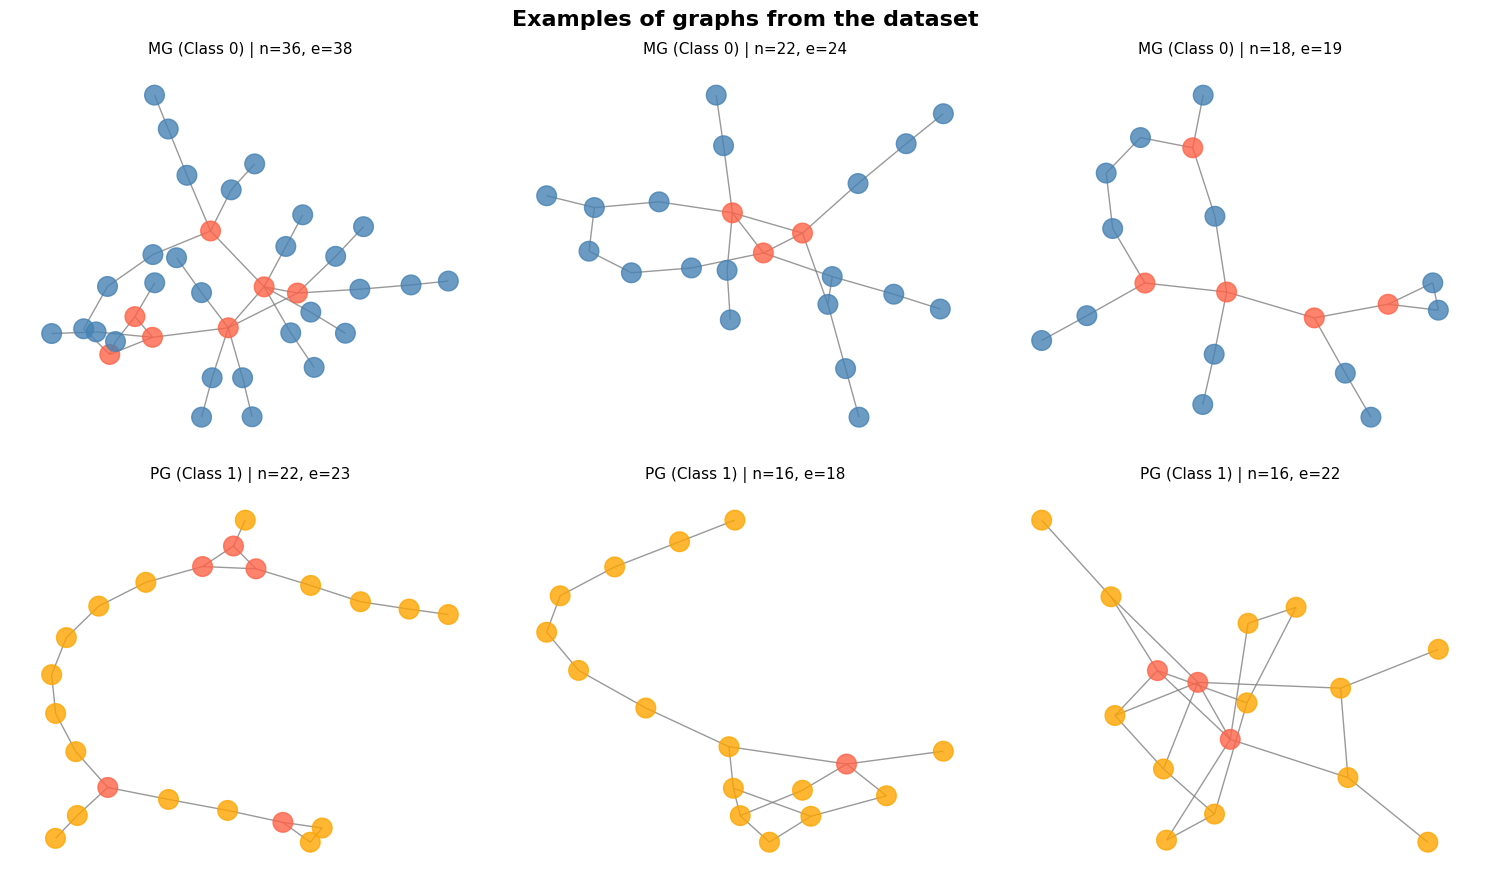

In [123]:
def draw_graph_on_axis(
    ax, G, id, title_prefix, hub_color="tomato", default_color="steelblue"
):
    degrees = dict(G.degree())
    mean_degree = np.mean(list(degrees.values())) if degrees else 0

    # Hubs are highlighted in red
    node_colors = [
        hub_color if degrees[n] > mean_degree * 1.4 else default_color
        for n in G.nodes()
    ]

    pos = nx.spring_layout(G, seed=42)

    nx.draw(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=200,
        edge_color="gray",
        alpha=0.8,
        with_labels=False,
    )

    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    ax.set_title(
        f"{title_prefix} (Class {id}) | n={n_nodes}, e={n_edges}", fontsize=11
    )


fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Examples of graphs from the dataset", fontsize=16, fontweight="bold")

mg_indices = [i for i, l in enumerate(labels) if l == 0][:3]
pg_indices = [i for i, l in enumerate(labels) if l == 1][:3]

# Class 0
for col, idx in enumerate(mg_indices):
    draw_graph_on_axis(
        ax=axes[0, col],
        G=graphs[idx],
        id=0,
        title_prefix="MG",
        hub_color="tomato",
        default_color="steelblue",
    )

# Class 1
for col, idx in enumerate(pg_indices):
    draw_graph_on_axis(
        ax=axes[1, col],
        G=graphs[idx],
        id=1,
        title_prefix="PG",
        hub_color="tomato",
        default_color="orange",
    )

plt.tight_layout()
plt.show()

Визуально классы отличаются:
 - у `MG`-графов есть выраженные хабы (красные узлы), от которых расходятся цепочки;
 - У `PG`-графов структура более однородная - степени вершин распределены равномернее, явных хабов нет.

## Shortest Path (`SP`) Kernel

Первое ядро описывает граф через гистограмму длин кратчайших путей между всеми парами вершин.

- `K_train` - матрица попарных сравнений тренировочных графов между собой, используется для обучения SVM;
- `K_test` - матрица сравнений тестовых графов с тренировочными, используется для предсказания.

#### Смысл функций:

- `compute_sp_feature_vector` вычисляет вектор признаков для одного графа на основе кратчайших путей;
- `shortest_path_kernel` вычисляет матрицы ядра на основе `SP`.


In [ ]:
def compute_sp_feature_vector(G, max_length=None):
    path_length_counts = defaultdict(int)

    for source, lengths in nx.shortest_path_length(G):
        for target, length in lengths.items():
            if source < target and length > 0:
                if max_length is None or length <= max_length:
                    path_length_counts[length] += 1

    return path_length_counts


def shortest_path_kernel(train_graphs, test_graphs):
    all_graphs = train_graphs + test_graphs
    n_train = len(train_graphs)

    # Сalculate histograms for all graphs
    feature_dicts = [compute_sp_feature_vector(G) for G in all_graphs]

    # Define the common space of path lengths
    all_lengths = set()
    for fd in feature_dicts:
        all_lengths.update(fd.keys())
    all_lengths = sorted(all_lengths)
    print(f"Path length range: {min(all_lengths)} - {max(all_lengths)}")

    # Constructing dense normalized vectors
    def to_vector(fd):
        vec = np.array([fd.get(k, 0) for k in all_lengths], dtype=float)
        norm = np.linalg.norm(vec)
        return vec / norm if norm > 0 else vec

    vectors = [to_vector(fd) for fd in feature_dicts]
    train_vecs = np.array(vectors[:n_train])
    test_vecs = np.array(vectors[n_train:])

    K_train = train_vecs @ train_vecs.T
    K_test = test_vecs @ train_vecs.T

    return K_train, K_test

### Распределение длин путей по классам

Посмотрим, действительно ли распределения кратчайших путей у двух классов отличаются.

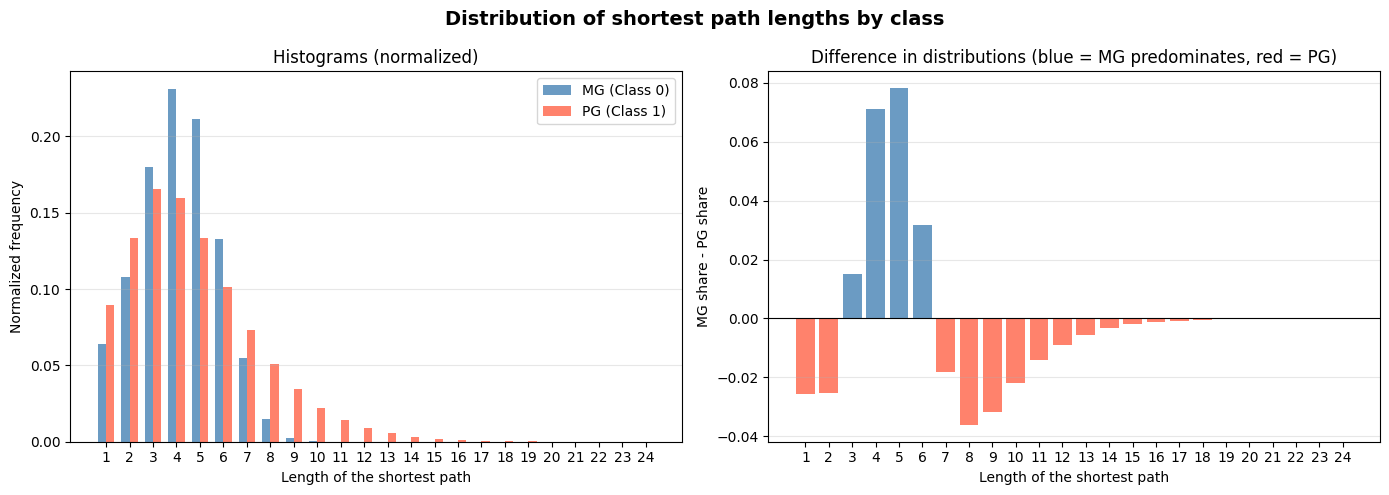

In [ ]:
mg_lengths = defaultdict(int)
pg_lengths = defaultdict(int)

for i, G in enumerate(graphs):
    fd = compute_sp_feature_vector(G)
    target = mg_lengths if labels[i] == 0 else pg_lengths
    for k, v in fd.items():
        target[k] += v

all_keys = sorted(set(mg_lengths) | set(pg_lengths))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Distribution of shortest path lengths by class", fontsize=14, fontweight="bold"
)

# Normalize for comparison
mg_vals = np.array([mg_lengths.get(k, 0) for k in all_keys], dtype=float)
pg_vals = np.array([pg_lengths.get(k, 0) for k in all_keys], dtype=float)
mg_vals /= mg_vals.sum()
pg_vals /= pg_vals.sum()

x = np.arange(len(all_keys))
width = 0.35

axes[0].bar(
    x - width / 2, mg_vals, width, label="MG (Class 0)", color="steelblue", alpha=0.8
)
axes[0].bar(
    x + width / 2, pg_vals, width, label="PG (Class 1)", color="tomato", alpha=0.8
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_keys)
axes[0].set_xlabel("Length of the shortest path")
axes[0].set_ylabel("Normalized frequency")
axes[0].set_title("Histograms (normalized)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Difference in distributions
diff = mg_vals - pg_vals
colors = ["steelblue" if d > 0 else "tomato" for d in diff]
axes[1].bar(x, diff, color=colors, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_keys)
axes[1].set_xlabel("Length of the shortest path")
axes[1].set_ylabel("MG share - PG share")
axes[1].set_title("Difference in distributions (blue = MG predominates, red = PG)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Распределения различаются:
 - `MG`- графы имеют больше путей средней длины (3-6): хабы соединяют разные части графа, создавая много путей похожей длины;
 - `PG`- графы содержат больше как коротких путей (1–2, за счёт пересечений цепочек), так и длинных (7+, за счёт линейных участков).

Это различие и использует SP Kernel.

## 4. Weisfeiler-Lehman (`WL`) Kernel

Второе ядро работает иначе: вместо расстояний оно смотрит на локальную топологию вокруг каждой вершины - алгоритм итеративно "раскрашивает" граф.  
Через $k$ итераций каждая вершина "знает" о своём окружении на расстоянии до $k$ рёбер.

#### Смысл функций:
- `compute_wl_feature_vector` вычисляет WL-признаки для одного графа;
- `wl_kernel` - сам `WL` Kernel.

In [ ]:
def compute_wl_feature_vector(G, n_iterations=3):
    # Initial labels are the degrees of the vertices
    labels = {node: str(G.degree(node)) for node in G.nodes()}

    histograms = [Counter(labels.values())]  # iteration 0

    for _ in range(n_iterations):
        new_labels = {}
        for node in G.nodes():
            # Collect neighbor labels, sort for order invariance
            neighbor_labels = sorted([labels[nb] for nb in G.neighbors(node)])
            # New label = hash of current label + labels of neighbors
            new_label = str(hash((labels[node], tuple(neighbor_labels))))
            new_labels[node] = new_label
        labels = new_labels
        histograms.append(Counter(labels.values()))

    return histograms


def wl_kernel(train_graphs, test_graphs, n_iterations=3):
    all_graphs = train_graphs + test_graphs
    n_train = len(train_graphs)

    # Calculating WL-histograms
    all_histograms = [compute_wl_feature_vector(G, n_iterations) for G in all_graphs]

    # Collect all unique colors by iterations
    color_sets = [set() for _ in range(n_iterations + 1)]
    for hists in all_histograms:
        for it, hist in enumerate(hists):
            color_sets[it].update(hist.keys())
    color_lists = [sorted(cs) for cs in color_sets]

    # Construct a dense vector (concatenation over all iterations)
    def to_vector(hists):
        parts = []
        for it, hist in enumerate(hists):
            parts.append([hist.get(c, 0) for c in color_lists[it]])
        vec = np.array([x for part in parts for x in part], dtype=float)
        norm = np.linalg.norm(vec)
        return vec / norm if norm > 0 else vec

    vectors = [to_vector(h) for h in all_histograms]
    train_vecs = np.array(vectors[:n_train])
    test_vecs = np.array(vectors[n_train:])

    K_train = train_vecs @ train_vecs.T
    K_test = test_vecs @ train_vecs.T

    return K_train, K_test

## Разбивка на train/test

Делим датасет на тренировочную (80%) и тестовую (20%) части.

In [ ]:
idx = np.arange(len(graphs))
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, labels, test_size=0.2, random_state=42, stratify=labels
)

train_graphs = [graphs[i] for i in idx_train]
test_graphs = [graphs[i] for i in idx_test]

print(f"Train: {len(train_graphs)} graphs | Test: {len(test_graphs)} graphs")
print(f"Train balance - Class 0: {sum(y_train==0)}, Class 1: {sum(y_train==1)}")
print(f"Test balance - Class 0: {sum(y_test==0)}, Class 1: {sum(y_test==1)}")

Train: 800 graphs | Test: 200 graphs
Train balance - Class 0: 400, Class 1: 400
Test balance - Class 0: 100, Class 1: 100


### Вычисление матриц ядра - `SP` Kernel

In [ ]:
K_train_sp, K_test_sp = shortest_path_kernel(train_graphs, test_graphs)
print(f"K_train shape: {K_train_sp.shape}")
print(f"K_test shape: {K_test_sp.shape}")

Path length range: 1 - 24
K_train shape: (800, 800)
K_test shape: (200, 800)


### Вычисление матриц ядра - `WL` Kernel

In [ ]:
K_train_wl, K_test_wl = wl_kernel(train_graphs, test_graphs, n_iterations=3)
print(f"K_train shape: {K_train_wl.shape}")
print(f"K_test shape: {K_test_wl.shape}")

K_train shape: (800, 800)
K_test shape: (200, 800)


### Визуализация матриц ядра

Визуализируем `K_train`, отсортировав графы по классам.

Хорошее ядро должно давать блочную структуру: графы одного класса похожи друг на друга (яркие блоки по диагонали), графы разных классов - менее похожи (более тёмные блоки вне диагонали).

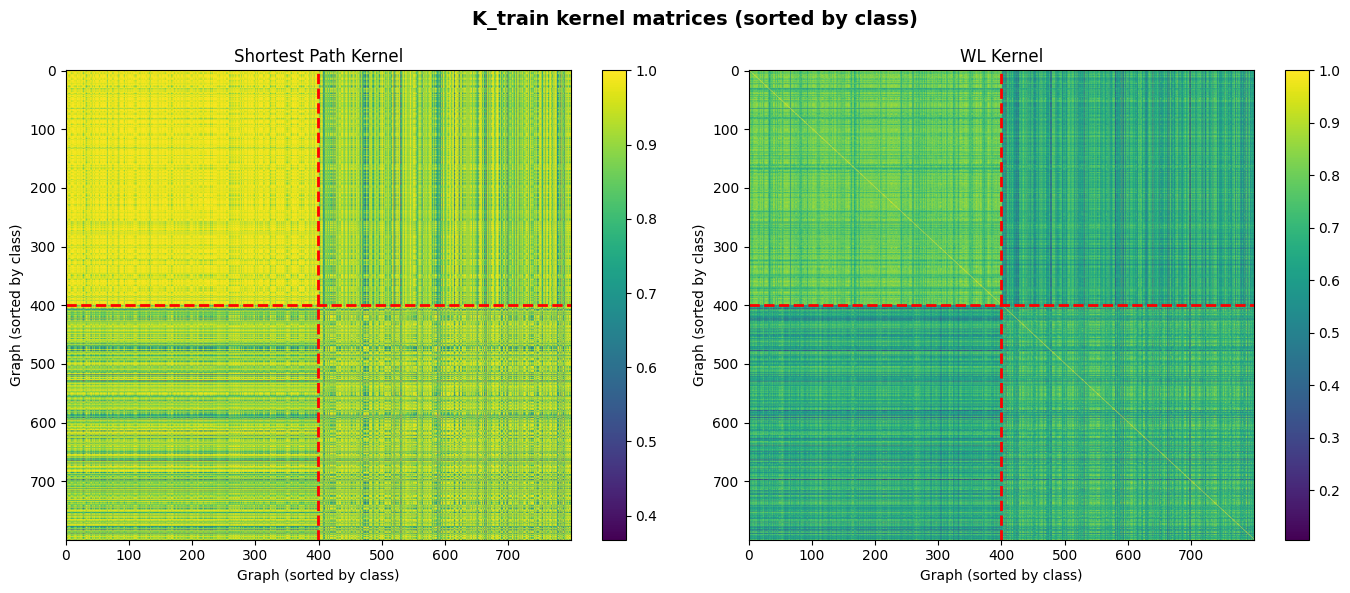

In [ ]:
# Sort by tags to make the block structure clearer
sort_idx = np.argsort(y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "K_train kernel matrices (sorted by class)", fontsize=14, fontweight="bold"
)

for ax, K, title in zip(
    axes,
    [K_train_sp[np.ix_(sort_idx, sort_idx)], K_train_wl[np.ix_(sort_idx, sort_idx)]],
    ["Shortest Path Kernel", "WL Kernel"],
):
    im = ax.imshow(K, cmap="viridis", aspect="auto")
    plt.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Graph (sorted by class)")
    ax.set_ylabel("Graph (sorted by class)")
    # Dividing line between classes
    sep = sum(y_train == 0)
    ax.axhline(sep - 0.5, color="red", linewidth=2, linestyle="--")
    ax.axvline(sep - 0.5, color="red", linewidth=2, linestyle="--")

plt.tight_layout()
plt.show()

У `SP` Kernel диагональные блоки выражены, но разница между блоками относительно небольшая - значения ядра для разных классов тоже довольно высокие.

У `WL` Kernel контраст между блоками заметнее: внутриклассовое сходство выше, межклассовое - ниже.  
Это соответствует лучшему качеству классификации WL на тесте.

## Обучение SVC с подбором гиперпараметров

Подбираемый гиперпараметр - **C** (параметр регуляризации):
- Малый C: модель допускает ошибки на тренировочных данных, но лучше обобщается;
- Большой C: модель старается разделить все тренировочные примеры верно, рискуя переобучиться.

In [147]:
def train_and_evaluate(K_train, K_test, y_train, y_test, kernel_name):
    print(f"=== {kernel_name} ===")
    param_grid = {
        "C": [0.1, 1.0, 10.0, 50.0, 100.0, 150.0],
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    svc = SVC(kernel="precomputed", probability=True, random_state=42)

    grid_search = GridSearchCV(
        svc, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=0
    )
    grid_search.fit(K_train, y_train)

    best_C = grid_search.best_params_["C"]
    best_cv_score = grid_search.best_score_
    print(f"Лучший C: {best_C}  |  CV F1-macro: {best_cv_score:.4f}")

    # Prediction on test
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(K_test)
    y_proba = best_model.predict_proba(K_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\nМетрики на тестовых данных:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1-macro:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["MG (0)", "PG (1)"]))

    return {
        "name": kernel_name,
        "best_C": best_C,
        "cv_f1": best_cv_score,
        "accuracy": acc,
        "f1": f1,
        "roc_auc": roc_auc,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "cv_results": grid_search.cv_results_,
        "param_grid": param_grid,
    }


results_sp = train_and_evaluate(
    K_train_sp, K_test_sp, y_train, y_test, "Shortest Path Kernel + SVC"
)
results_wl = train_and_evaluate(
    K_train_wl, K_test_wl, y_train, y_test, "Weisfeiler-Lehman Kernel + SVC"
)

=== Shortest Path Kernel + SVC ===


Лучший C: 100.0  |  CV F1-macro: 0.9400

Метрики на тестовых данных:
  Accuracy:  0.9350
  F1-macro:  0.9350
  ROC-AUC:   0.9866

Classification Report:
              precision    recall  f1-score   support

      MG (0)       0.95      0.92      0.93       100
      PG (1)       0.92      0.95      0.94       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.93       200
weighted avg       0.94      0.94      0.93       200

=== Weisfeiler-Lehman Kernel + SVC ===
Лучший C: 50.0  |  CV F1-macro: 0.9625

Метрики на тестовых данных:
  Accuracy:  0.9800
  F1-macro:  0.9800
  ROC-AUC:   0.9972

Classification Report:
              precision    recall  f1-score   support

      MG (0)       0.99      0.97      0.98       100
      PG (1)       0.97      0.99      0.98       100

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



## Сравнение результатов

Построим сводную таблицу результатов с выводом победителя по каждой метрике.

In [145]:
metrics = ["accuracy", "f1", "roc_auc"]
metric_labels = ["Accuracy", "F1-macro", "ROC-AUC"]

data = []
for m, ml in zip(metrics, metric_labels):
    sp_val = results_sp[m]
    wl_val = results_wl[m]

    if sp_val > wl_val:
        winner = "SP"
    elif wl_val > sp_val:
        winner = "WL"
    else:
        winner = "Tie"

    data.append(
        {"Метрика": ml, "SP Kernel": sp_val, "WL Kernel": wl_val, "Лучший": winner}
    )

df = pd.DataFrame(data)

df["SP Kernel"] = df["SP Kernel"].apply(lambda x: f"{x:.4f}")
df["WL Kernel"] = df["WL Kernel"].apply(lambda x: f"{x:.4f}")

df.style.hide(axis="index")

Метрика,SP Kernel,WL Kernel,Лучший
Accuracy,0.9350,0.9800,WL
F1-macro,0.9350,0.9800,WL
ROC-AUC,0.9866,0.9972,WL


### Детальное сравнение

Построим серию графиков/диаграмм:
1. Confusion matrix показывает, какие именно ошибки делает каждая модель;
2. Графики подбора C показывают, насколько стабильно качество при разных значениях регуляризации;
3. Столбчатая диаграмма показывает результаты метрик.

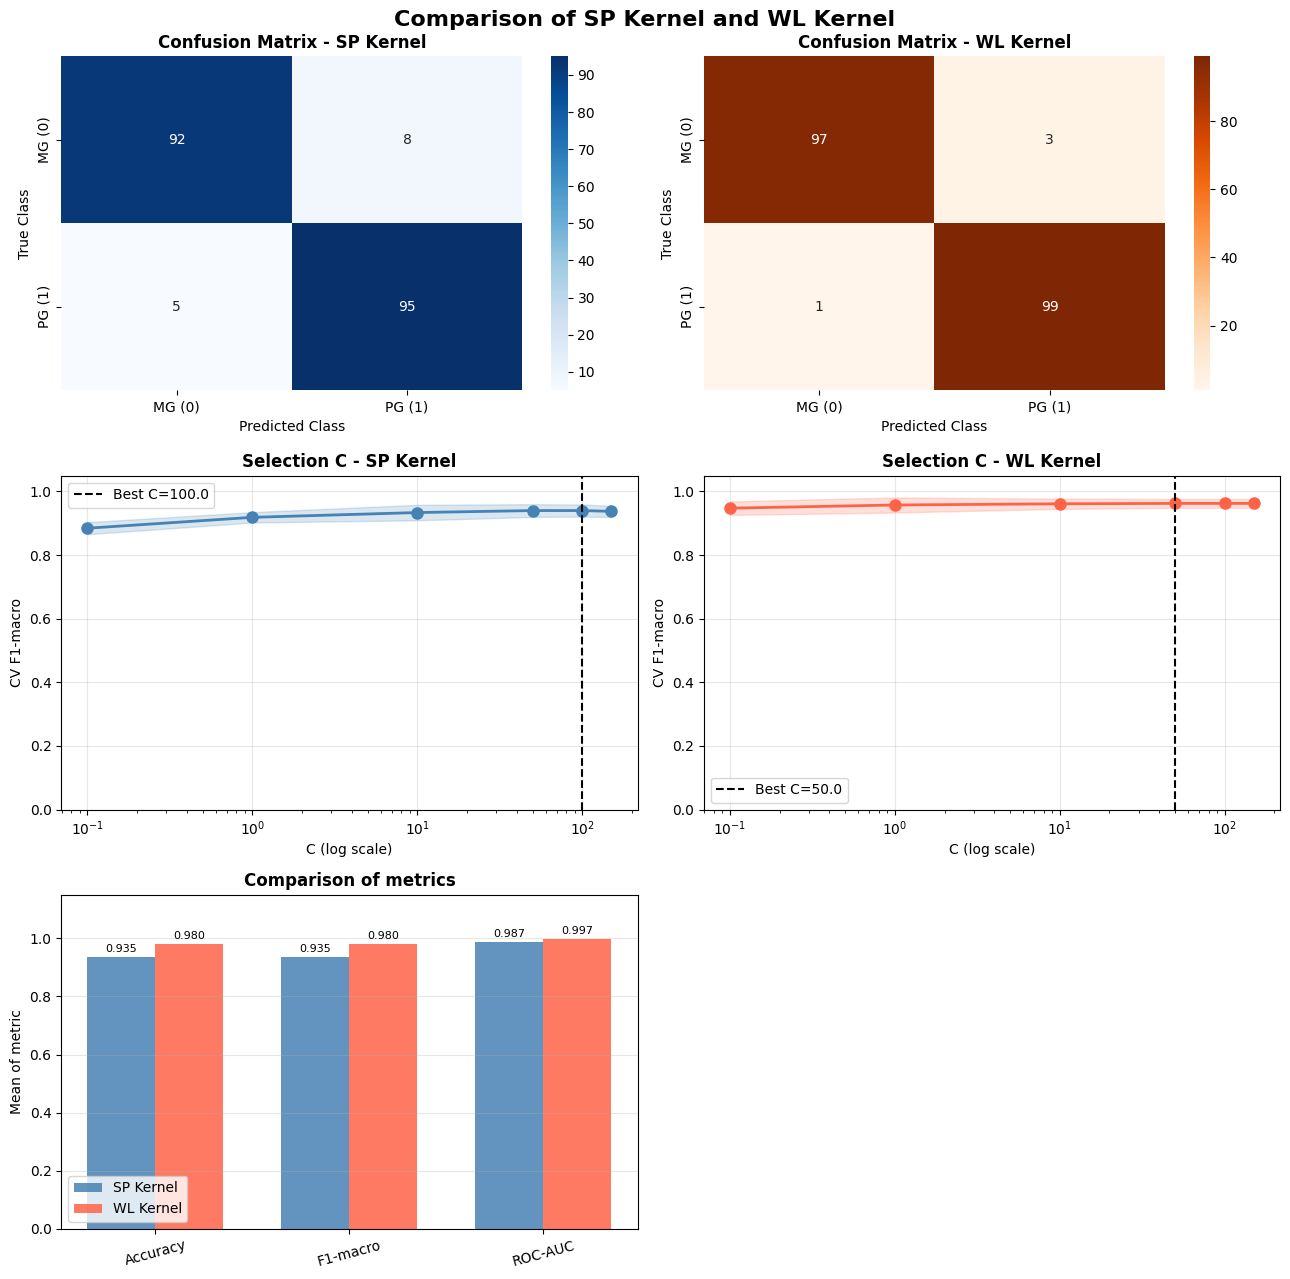

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13, 13))
fig.suptitle("Comparison of SP Kernel and WL Kernel", fontsize=16, fontweight="bold")

# SP Error Matrix
cm_sp = confusion_matrix(y_test, results_sp["y_pred"])
sns.heatmap(
    cm_sp,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0, 0],
    xticklabels=["MG (0)", "PG (1)"],
    yticklabels=["MG (0)", "PG (1)"],
)
axes[0, 0].set_title("Confusion Matrix - SP Kernel", fontweight="bold")
axes[0, 0].set_ylabel("True Class")
axes[0, 0].set_xlabel("Predicted Class")

# WL Error Matrix
cm_wl = confusion_matrix(y_test, results_wl["y_pred"])
sns.heatmap(
    cm_wl,
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=axes[0, 1],
    xticklabels=["MG (0)", "PG (1)"],
    yticklabels=["MG (0)", "PG (1)"],
)
axes[0, 1].set_title("Confusion Matrix - WL Kernel", fontweight="bold")
axes[0, 1].set_ylabel("True Class")
axes[0, 1].set_xlabel("Predicted Class")

# CV-curves for C
for ax, res, color, label in zip(
    [axes[1, 0], axes[1, 1]],
    [results_sp, results_wl],
    ["steelblue", "tomato"],
    ["SP Kernel", "WL Kernel"],
):
    C_vals = [p["C"] for p in res["cv_results"]["params"]]
    mean_scores = res["cv_results"]["mean_test_score"]
    std_scores = res["cv_results"]["std_test_score"]
    ax.semilogx(C_vals, mean_scores, "o-", color=color, linewidth=2, markersize=8)
    ax.fill_between(
        C_vals,
        mean_scores - std_scores,
        mean_scores + std_scores,
        alpha=0.2,
        color=color,
    )
    ax.axvline(
        res["best_C"],
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f'Best C={res["best_C"]}',
    )
    ax.set_xlabel("C (log scale)")
    ax.set_ylabel("CV F1-macro")
    ax.set_title(f"Selection C - {label}", fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)

# Comparison of metrics
x = np.arange(len(metric_labels))
width = 0.35
sp_vals = [results_sp[m] for m in metrics]
wl_vals = [results_wl[m] for m in metrics]

bars1 = axes[2, 0].bar(
    x - width / 2, sp_vals, width, label="SP Kernel", color="steelblue", alpha=0.85
)
bars2 = axes[2, 0].bar(
    x + width / 2, wl_vals, width, label="WL Kernel", color="tomato", alpha=0.85
)

axes[2, 0].set_ylim(0, 1.15)
axes[2, 0].set_xticks(x)
axes[2, 0].set_xticklabels(metric_labels, rotation=15)
axes[2, 0].set_ylabel("Mean of metric")
axes[2, 0].set_title("Comparison of metrics", fontweight="bold")
axes[2, 0].legend()
axes[2, 0].grid(axis="y", alpha=0.3)

for bar in bars1:
    axes[2, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
for bar in bars2:
    axes[2, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

axes[2, 1].axis("off")

plt.tight_layout()
plt.show()

### Выводы

- `WL` Kernel ошибается на 4 графах из 200 (3 `MG` приняты за `PG` и 1 `PG` за `MG`).

- `SP` Kernel - на 13 (8 `MG` и 5 `PG`). Оба ядра уверены в большинстве предсказаний (`ROC-AUC` > 0.98), однако `WL` Kernel точнее разграничивает классы.

Это согласуется с теорией: `WL` улавливает локальную топологию (наличие хабов, структуру окружения вершин), которую `SP` Kernel описывает лишь косвенно через распределение расстояний.